#  Building an Image Classifier with CNN (MNIST)

**Objective:**
To build a CNN to classify handwritten digits (0–9) using MNIST; evaluate on test set (target ≥98%); test on custom digit images.

**Dataset:** MNIST Handwritten Digits Dataset (60,000 train / 10,000 test, 28×28 grayscale)

 - Dataset Link: https://www.tensorflow.org/datasets/catalog/mnist

## 1. Import Libraries & Load Dataset
 We will use TensorFlow/Keras to load MNIST (train/test split) and visualize sample images.

In [121]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt

# TensorFlow / Keras: building, training, and saving the CNN model
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# For metrics/visualizations for evaluation
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [122]:
# Print TensorFlow version for reproducibility
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In [123]:
# Load MNIST Dataset

# MNIST comes with Keras and contains 60,000 training images and 10,000 test images
# Each image is grayscale 28x28 and labels are digits 0-9

(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

In [124]:
# Display shapes to confirm successful loading
print("x_train shape:", x_train.shape, "| y_train shape:", y_train.shape)
print("x_test shape :", x_test.shape,  "| y_test shape :", y_test.shape)

x_train shape: (60000, 28, 28) | y_train shape: (60000,)
x_test shape : (10000, 28, 28) | y_test shape : (10000,)


## 2. Visualize Sample Images
Display a few training samples to understand the dataset.

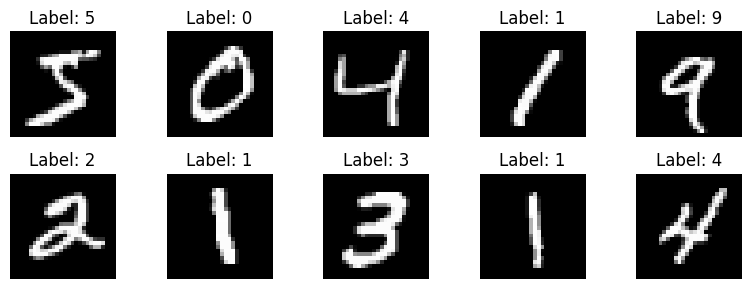

In [125]:
# Visualize a few training images
plt.figure(figsize=(8, 3))

for i in range(10):
    # Create a 2x5 grid of images
    plt.subplot(2, 5, i + 1)

    # Show image in grayscale
    plt.imshow(x_train[i], cmap="gray")

    # Show its label as the title
    plt.title(f"Label: {y_train[i]}")

    # Remove axis ticks for clean visualization
    plt.axis("off")

plt.tight_layout()
plt.show()

## 3. Data Preprocessing
Normalize pixels to [0,1], Reshape to (28,28,1), and One-hot encode labels

In [126]:
# Data Preprocessing Step

# 1) Normalize images: scale pixel values from [0,255] to [0,1]
# This helps the neural network train faster and more stably.
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

# 2) Reshape images to include a "channel" dimension (grayscale => 1 channel)
#    CNN expects input shape: (height, width, channels)
x_train = np.expand_dims(x_train, axis=-1)  # (60000, 28, 28, 1)
x_test  = np.expand_dims(x_test, axis=-1)   # (10000, 28, 28, 1)

# 3) One-hot encode labels: convert digit labels into vectors of length 10
#    Example: digit 3 => [0,0,0,1,0,0,0,0,0,0]
num_classes = 10
y_train_cat = keras.utils.to_categorical(y_train, num_classes)
y_test_cat  = keras.utils.to_categorical(y_test, num_classes)

# Confirm the transformed shapes
print("After preprocessing:")
print("x_train shape:", x_train.shape, "| y_train_cat shape:", y_train_cat.shape)
print("x_test shape :", x_test.shape,  "| y_test_cat shape :", y_test_cat.shape)

After preprocessing:
x_train shape: (60000, 28, 28, 1) | y_train_cat shape: (60000, 10)
x_test shape : (10000, 28, 28, 1) | y_test_cat shape : (10000, 10)


## 4) Build the CNN Model
 **CNN Model Architecture:**
 convolutional layers + max-pooling (for feature extraction) + dropout layers (to prevent overfitting) + dense fully connected layer (to output preditions)+ softmax output layer for multi-class classification (digits 0–9)

In [127]:
# Building the Convolutional Neural Network Model

# - Conv2D layers extracts features (edges, curves)
# - MaxPooling reduces spatial size and keeps strong features
# - Dropout layers reduces overfitting
# - Dense FCL + Softmax outputs probabilities for 10 classes (digits 0-9)

input_shape = (28, 28, 1)

model = keras.Sequential([
    # Define expected input shape
    keras.Input(shape=input_shape),

    # First convolution block
    layers.Conv2D(32, kernel_size=(3, 3), activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2)),

    # Second convolution block
    layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2)),

    # Flatten feature maps into a vector
    layers.Flatten(),

    # Dropout to reduce overfitting
    layers.Dropout(0.5),

    # Softmax layer outputs class probabilities for digits 0-9
    layers.Dense(num_classes, activation="softmax")
])

# Print model summary for documentation/screenshot
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Compile & Train the CNN Model
Train for 10 epochs and monitor the validation metrics

In [128]:
# Compile the CNN Model

# Optimizer: Adam (commonly used, fast convergence)
# Loss: categorical_crossentropy (multi-class classification with one-hot labels)
# Metric: accuracy

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


# Train the CNN Model
# Keep 10% of training data for validation monitoring

epochs = 7
batch_size = 128

history = model.fit(
    x_train, y_train_cat,
    validation_split=0.1,
    epochs=epochs,
    batch_size=batch_size,
    verbose=1
)

Epoch 1/7
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 95ms/step - accuracy: 0.8832 - loss: 0.3824 - val_accuracy: 0.9797 - val_loss: 0.0816
Epoch 2/7
422/422 ━━━━━━━━━━━━━━━━━━━━ 40s 94ms/step - accuracy: 0.9659 - loss: 0.1122 - val_accuracy: 0.9850 - val_loss: 0.0584
Epoch 3/7
422/422 ━━━━━━━━━━━━━━━━━━━━ 40s 95ms/step - accuracy: 0.9744 - loss: 0.0843 - val_accuracy: 0.9862 - val_loss: 0.0497
Epoch 4/7
422/422 ━━━━━━━━━━━━━━━━━━━━ 40s 95ms/step - accuracy: 0.9784 - loss: 0.0683 - val_accuracy: 0.9877 - val_loss: 0.0428
Epoch 5/7
422/422 ━━━━━━━━━━━━━━━━━━━━ 36s 84ms/step - accuracy: 0.9812 - loss: 0.0609 - val_accuracy: 0.9898 - val_loss: 0.0370
Epoch 6/7
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 84ms/step - accuracy: 0.9820 - loss: 0.0559 - val_accuracy: 0.9900 - val_loss: 0.0351
Epoch 7/7
422/422 ━━━━━━━━━━━━━━━━━━━━ 36s 85ms/step - accuracy: 0.9841 - loss: 0.0501 - val_accuracy: 0.9905 - val_loss: 0.0318


## 6) Training Curves
Plot accuracy/loss for train and validation to show convergence.

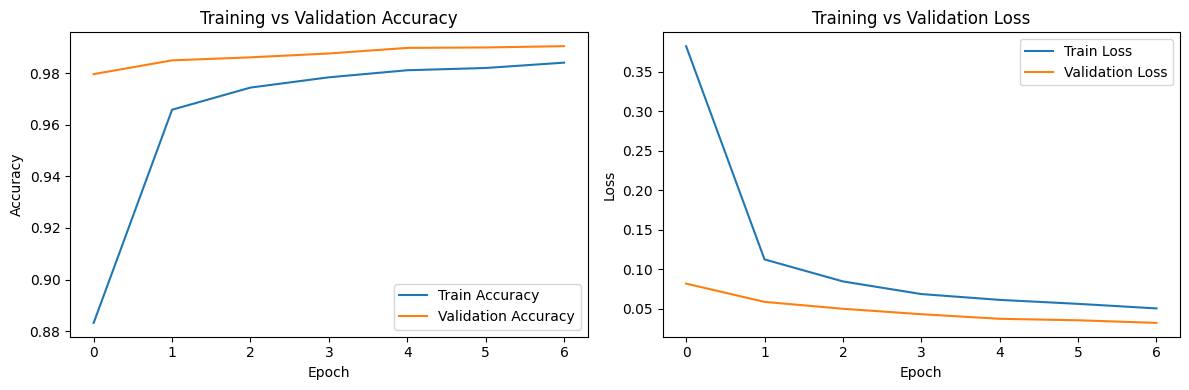

In [129]:
# Plot training curves (Accuracy & Loss)
# These plots help show whether the model is learning and whether it overfits.

plt.figure(figsize=(12, 4))

# Plot accuracy curve
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Plot loss curve
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

## 7) Model Evaluation on the Test Set
Evaluating the model on the test set to see whether we get a high accuracy rate.


In [130]:
# Evaluating on the Test Set

test_loss, test_acc = model.evaluate(x_test, y_test_cat, verbose=0)

print(f"Test Accuracy: {test_acc * 100:.2f}%")
print(f"Test Loss    : {test_loss:.4f}")

Test Accuracy: 99.08%
Test Loss    : 0.0295


In [131]:
# Classification Report on the Test Set
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       0.99      1.00      0.99      1135
           2       0.98      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      1.00      0.99       982
           5       0.98      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.98      0.99      0.98      1028
           8       0.99      0.98      0.99       974
           9       0.99      0.98      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



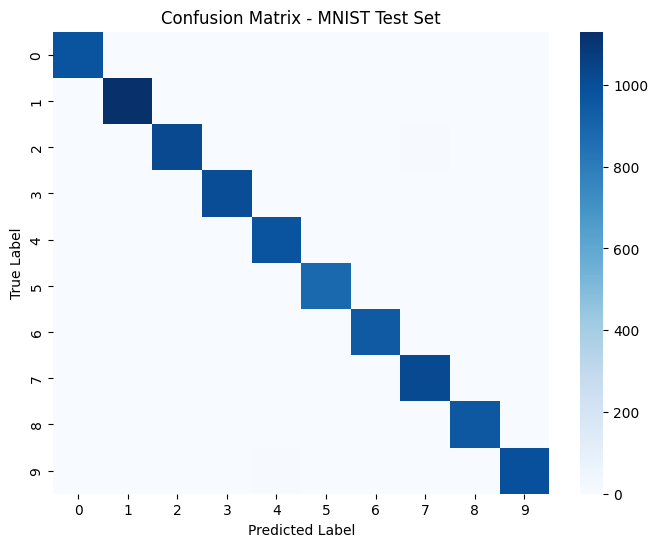

In [132]:
# Confusion Matrix on the Test Set

y_pred_probs = model.predict(x_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, cmap="Blues", annot=False, fmt="d")
plt.title("Confusion Matrix - MNIST Test Set")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

## 8) Save the Trained Model

In [133]:
# Save the Trained Model

# Keras native format (.keras) is recommended for portability.
# Also saving .h5 for compatibility.

import os
os.makedirs("models", exist_ok=True)

model.save("models/mnist_cnn.keras")
model.save("models/mnist_cnn.h5")

print("Model saved to:")
print(" - models/mnist_cnn.keras")
print(" - models/mnist_cnn.h5")

Model saved to:
 - models/mnist_cnn.keras
 - models/mnist_cnn.h5


## 9) Test on Custom Handwritten Digit Images
 Upload custom images, ensure 28×28 sizes, normalize, predict, and summarize predictions.

In [134]:
# Upload custom images in Colab
# You can upload PNG/JPG images of handwritten digits.
from google.colab import files
uploaded = files.upload()

Saving Custom Image 0.jpg to Custom Image 0.jpg
Saving Custom Image 9.jpg to Custom Image 9.jpg
Saving Custom Image 8.jpg to Custom Image 8.jpg
Saving Custom Image 7.jpg to Custom Image 7.jpg
Saving Custom Image 6.jpg to Custom Image 6.jpg
Saving Custom Image 5.jpg to Custom Image 5.jpg
Saving Custom Image 4.jpg to Custom Image 4.jpg
Saving Custom Image 3.jpg to Custom Image 3.jpg
Saving Custom Image 2.jpg to Custom Image 2.jpg
Saving Custom Image 1.jpg to Custom Image 1.jpg


In [135]:
# Preprocess Custom Images to Match MNIST Format

# The model was trained on MNIST-like images (grayscale, 28x28, pixel values in [0,1])
# This function converts any uploaded digit image to that format.
from PIL import Image, ImageOps, ImageFilter
import pandas as pd

def preprocess_custom_image(path, invert=True):
    # Convert to grayscale
    im = Image.open(path).convert("L")

    # Improve contrast (helps if photo is faint)
    im = ImageOps.autocontrast(im)

    # Resize digit to fit within a 20x20 box while keeping aspect ratio
    w, h = im.size
    if w > h:
        new_w = 20
        new_h = max(1, int(round(20.0 * h / w)))
    else:
        new_h = 20
        new_w = max(1, int(round(20.0 * w / h)))

    # Resize and sharpen
    im = im.resize((new_w, new_h), Image.Resampling.LANCZOS).filter(ImageFilter.SHARPEN)

    # Create a 28x28 white canvas and paste the digit roughly centered
    canvas = Image.new("L", (28, 28), color=255)
    left = (28 - new_w) // 2
    top  = (28 - new_h) // 2
    canvas.paste(im, (left, top))

    # MNIST digits are typically "light background + dark digit".
    # If your custom image is dark background/light digit, invert=True helps.
    if invert:
        canvas = ImageOps.invert(canvas)

    # Convert to NumPy and normalize to [0,1]
    arr = np.array(canvas).astype("float32") / 255.0

    # Add batch + channel dims => (1, 28, 28, 1)
    arr = np.expand_dims(arr, axis=(0, -1))
    return canvas, arr

In [136]:
# Predict on Each Custom Image and Build a Summary Table
results = []

for fname in uploaded.keys():
    # Preprocess image into MNIST-like format
    disp_img, x = preprocess_custom_image(fname, invert=True)

    # Predict probabilities (length 10)
    probs = model.predict(x, verbose=0)[0]

    # Choose the class with highest probability
    pred_digit = int(np.argmax(probs))
    confidence = float(np.max(probs))

    results.append({
        "file": fname,
        "predicted_digit": pred_digit,
        "confidence": round(confidence, 4)
    })

df_results = pd.DataFrame(results).sort_values("file")
df_results

,file,predicted_digit,confidence
0,Custom Image 0.jpg,0,0.1284
9,Custom Image 1.jpg,2,0.1657
8,Custom Image 2.jpg,2,0.1893
7,Custom Image 3.jpg,3,0.2754
6,Custom Image 4.jpg,4,0.2320
5,Custom Image 5.jpg,5,0.2201
4,Custom Image 6.jpg,6,0.1702
3,Custom Image 7.jpg,3,0.1698
2,Custom Image 8.jpg,8,0.2168
1,Custom Image 9.jpg,9,0.2693


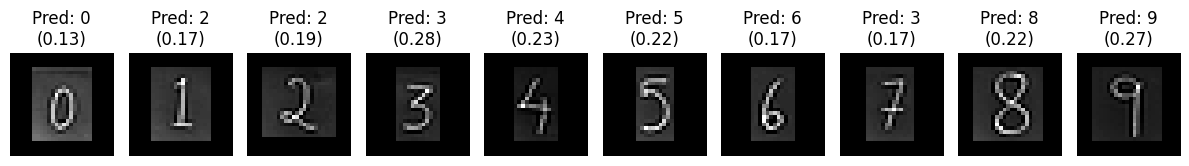

In [137]:
# Visualize Custom Image Predictions
plt.figure(figsize=(12, 3))

for i, row in enumerate(df_results.itertuples(index=False)):
    disp_img, _ = preprocess_custom_image(row.file, invert=True)

    plt.subplot(1, len(df_results), i + 1)
    plt.imshow(disp_img, cmap="gray")
    plt.title(f"Pred: {row.predicted_digit}\n({row.confidence:.2f})")
    plt.axis("off")

plt.tight_layout()
plt.show()